# Water level prediction using ERA5

## Problem description
Given a set of  5,000  nodes over the Northern Adriatic Sea, defined by varying longitude and latitude (visualized as red spots in image below), you are supposed to infer the water level of these points at each hour in a given range, using a neural network.

In [33]:
#import base64
#from IPython.display import HTML, display

#with open("graphical_visualization.png", "rb") as f:
#    encoded = base64.b64encode(f.read()).decode("utf-8")
#
#display(HTML(f"""<img src="data:image/png;base64,{encoded}" width="800"/>"""))

The information you can use to predict these values are:
* **latitude** and **longitude** of the nodes
* the **ephemerides** relative to the sun and the moon at each hour (we consider a single value of the ephemeridies for the whole region). Ephemerides are key predictors of tidal motion and are therefore important for the prediction of water level. The provided values of the ephemerides are already normalized.
* **weather variables** (wind components and pressure) derived from ERA5 dataset (not normalized). Due to the low resolution of ERA5, these values are organized as an array of shape $5 \times 9$ for each hour and each variable. A supporting function is provided to convert a given (latitude, longitude) of a node to the associated index of ERA5 array. Weather variables are important to predict phenomenon such as storm surge: another key component of water level.

For the prediction of the water level at timestamp $t$, you are allowed to use a sequence of any length of the input variables relative to past timesteps, but no future information. The output variable (corresponding to the **water level**) **CANNOT** be used as input to the model, not even for past timestamps.   


# Data Download

In [34]:
import gdown

In [35]:
!gdown 1NzYayIEoY_JzW9E-38ejnHahNlALlFBn
!gdown 1viecawNSkSEGUvEk7nu7rhKcRd5Q7wgm
!gdown 1aBCiXHEWN7ZeIlyj77qNCZ7DHwCUy9LG
!gdown 19m4hBBrup_Ast_ozGFDmVK-i7N2DUQC5
!gdown 1wtRof_MQJlE2GNplfbflAPR3cxpmiCeZ
!gdown 13q1PVFDcOTujx_r4fMPKxkJeMw4fAt5j
!gdown 1wVmxNvCg6Pe9Ol3LGM1NykXVwJiZUdE4
!gdown 1osjH0XjabPwZNuN8hKK1TcIvQ63Cfyda
!gdown 1epCvAsWYrCISdcbc2dXZArow5ouhsWjl

Downloading...
From (original): https://drive.google.com/uc?id=1NzYayIEoY_JzW9E-38ejnHahNlALlFBn
From (redirected): https://drive.google.com/uc?id=1NzYayIEoY_JzW9E-38ejnHahNlALlFBn&confirm=t&uuid=67ec79a3-f8e2-4490-8b7b-017bbabb68ed
To: /content/wl_2020.npy
100% 176M/176M [00:02<00:00, 68.2MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1viecawNSkSEGUvEk7nu7rhKcRd5Q7wgm
From (redirected): https://drive.google.com/uc?id=1viecawNSkSEGUvEk7nu7rhKcRd5Q7wgm&confirm=t&uuid=1380c05a-3897-456d-b4f4-e362cde5da0f
To: /content/wl_2010-2020.npy
100% 1.75G/1.75G [00:16<00:00, 105MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1aBCiXHEWN7ZeIlyj77qNCZ7DHwCUy9LG
To: /content/tvec_2010-2019.npy
100% 4.21M/4.21M [00:00<00:00, 23.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=19m4hBBrup_Ast_ozGFDmVK-i7N2DUQC5
To: /content/lon.npy
100% 20.1k/20.1k [00:00<00:00, 38.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wtRof_MQJlE2GNplfbflAPR3cxpmiCeZ
To: /

## We use cartopy for visualizations

In [36]:
!pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

In [37]:
import numpy as np
from tqdm import tqdm
from datetime import datetime

import matplotlib.pyplot as plt

In [38]:
# load nodes coordinates
lat_vec = np.load("./lat.npy") # (5000, )
lon_vec = np.load("./lon.npy") # (5000, )

#load train data
train_wl = np.load("./wl_2010-2020.npy") # (87648, 5000)
train_ephem = np.load("./dist_alt_az_moon-sun_coord13-45_2010-2019_norm.npy") # (6, 87648)
train_era5 = np.load("./ERA5_adriatic_u10v10sp_2010-2019.npy") # (3, 87648, 5, 9)
train_tvec = np.load("./tvec_2010-2019.npy") # (6, 87648))

T_train = train_wl.shape[0]
N_nodes = train_wl.shape[1]

#load test data
test_wl = np.load("./wl_2020.npy") # (8784, 5000)
test_ephem = np.load("./dist_alt_az_moon-sun_coord13-45_2020_norm.npy") # (6, 8784)
test_era5 = np.load("./ERA5_adriatic_u10v10sp_2020.npy")#(3, 8784, 5, 9)
test_tvec = np.load("./tvec_2020.npy") # (6,8784)

## Data description

**ERA5:**
- Gridded, hourly atmospheric data
- Spatial resolution: $5 \times 9$ grid over the study area
- 3 variables: u10, v10 (10m wind components), surface pressure
- explicit time: Year,Month,Day,Hour,Minute,Second

**EPHEMERIDES:**
- 6 scalar features describing Moon–Sun geometry
  (e.g. distance, altitude, azimuth)
- Hourly resolution
- Spatially constant (same values for all target nodes)

**TARGET:**
- Water level at 5000 spatial nodes in the Northern Adriatic
- Each node has fixed latitude and longitude
- A function is provided to match node coordinates to the closest era5 data



In [39]:
# utilities functions
def get_era5_coord(lat, lon):
    """
    Function to get era5 data from data coordinates
    """
    era5_row, era5_col = 5, 9
    lat_min, lat_max = 44.94972, 45.8
    lon_min, lon_max = 12.12863, 13.81283

    delta_lat = lat_max - lat_min
    delta_lon = lon_max - lon_min

    lon_coord = np.ceil((lon - lon_min) / delta_lon * (era5_col -1))
    lat_coord = 4 - np.ceil((lat - lat_min) / delta_lat * (era5_row - 1))

    return int(lat_coord), int(lon_coord)

def RMSE(wl_true, wl_pred):
    """
    Root mean squared error
    """
    return np.sqrt(np.mean(np.square(wl_pred - wl_true)))

In [40]:
#example of usage of get_era5_coord
node_number = np.random.randint(np.shape(test_wl)[1])
era5_coords = get_era5_coord(lat_vec[node_number], lon_vec[node_number])
print(f"ERA5 grid coords for node {node_number}: {era5_coords}")
hour = np.random.randint(np.shape(test_wl)[1])
print(test_tvec[:,hour])
hour_time = datetime(*test_tvec[:,hour].astype(int))
print(hour_time)
wind0,wind1,pression = test_era5[:,hour,era5_coords[0],era5_coords[1]]
print(f"node {node_number} at time {hour_time} (no {hour}): wind0 = {wind0:.3f}, wind1 = {wind1:1.3f}, pression ={pression:.3f}")

ERA5 grid coords for node 2787: (2, 7)
[2.02e+03 5.00e+00 2.20e+01 1.00e+00 0.00e+00 0.00e+00]
2020-05-22 01:00:00
node 2787 at time 2020-05-22 01:00:00 (no 3409): wind0 = -1.586, wind1 = 0.130, pression =99868.938


As you may observe, wind and especially pressure **are not normalized!!**

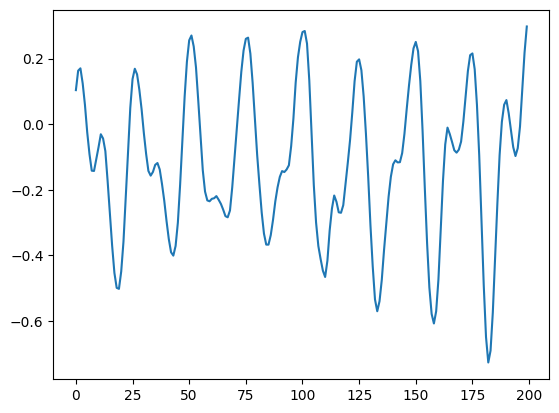

In [41]:
# Visualize a single node variability,
plt.plot(test_wl[:200, 0])

In the picture above you may easily recognize the tydal cycle, with a period of approximately 24 hours.

/usr/local/lib/python3.12/dist-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)


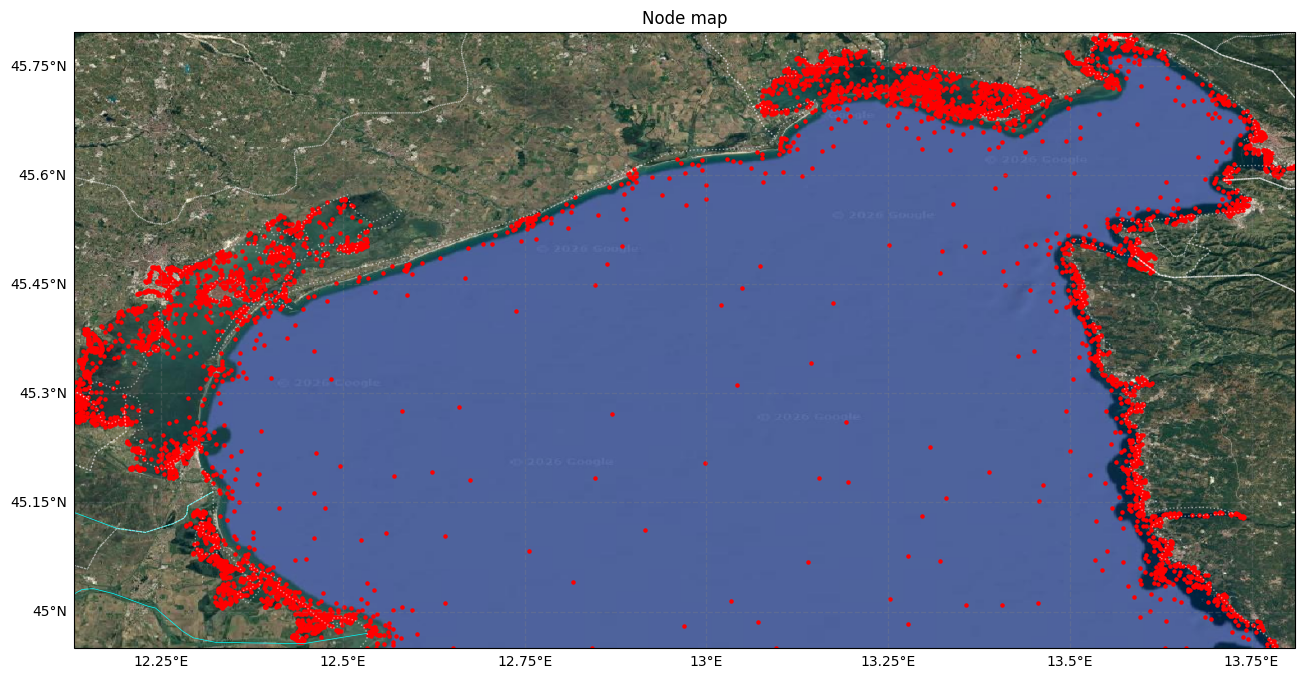

In [42]:
# Create figure and map
fig, ax = plt.subplots(figsize=(16, 8), subplot_kw={'projection': ccrs.PlateCarree()})
(lat_min, lat_max), (lon_min, lon_max) = (lat_vec.min(), lat_vec.max()), (lon_vec.min(), lon_vec.max())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

stamen_terrain = cimgt.GoogleTiles(style='satellite')
ax.add_image(stamen_terrain, 10)

ax.add_feature(cfeature.RIVERS, edgecolor='cyan', linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='white', alpha=0.5)
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='white', alpha=0.5)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.3, linestyle='--')
gl.top_labels = gl.right_labels = False

# Plot red dots
# Note: Ensure data is visible against the varied satellite background
sc = ax.scatter(lon_vec, lat_vec, cmap="viridis", c="r", s=5, marker='o', transform=ccrs.PlateCarree(), vmin=0.07, vmax=0.15)
# Increased 's' (size) slightly to make dots visible against satellite texture

plt.title(f'Node map')
plt.savefig("graphical_visualization.png", dpi=400)
plt.show()

# Data Normalisation

In [43]:
def normalize_data(X):
    return ((X-X.min()) / (X.max() - X.min()))

In [44]:
train_era5_norm = normalize_data(train_era5)
test_era5_norm = normalize_data(test_era5)

In [45]:
def time_encoding(tvec):
    years  = tvec[0].astype(int)
    months = tvec[1].astype(int)
    days   = tvec[2].astype(int)
    hours  = tvec[3].astype(int)

    leap = (years % 4 == 0) & ((years % 100 != 0) | (years % 400 == 0))
    month_days = np.array([31,28,31,30,31,30,31,31,30,31,30,31])
    cum_days = np.concatenate([[0], np.cumsum(month_days)])

    doy = cum_days[months - 1] + days
    doy += leap & (months > 2)

    hour_sin = np.sin(2 * np.pi * hours / 24.0)
    hour_cos = np.cos(2 * np.pi * hours / 24.0)
    doy_sin = np.sin(2 * np.pi * doy / 365.0)
    doy_cos = np.cos(2 * np.pi * doy / 365.0)

    return np.stack([hour_sin, hour_cos, doy_sin, doy_cos], axis=1)

train_time_feat = time_encoding(train_tvec)
test_time_feat  = time_encoding(test_tvec)
print("Time features:", train_time_feat.shape)

Time features: (87648, 4)


In [46]:
node_era5 = np.array([get_era5_coord(lat_vec[i], lon_vec[i]) for i in range(N_nodes)])
print(node_era5.shape, node_era5[:5])

(5000, 2) [[0 5]
 [2 7]
 [1 8]
 [3 1]
 [0 6]]


In [48]:
def build_features_pairs(t_idx, n_idx, ephem, time_feat, era5_norm):
    """Aligned pairs: t_idx[k], n_idx[k] -> one sample."""
    t_idx = np.asarray(t_idx)
    n_idx = np.asarray(n_idx)

    ep = ephem[:, t_idx].T
    tf = time_feat[t_idx]
    rows, cols = node_era5[n_idx].T
    er = era5_norm[:, t_idx, rows, cols].T
    latlon = np.stack([lat_vec[n_idx], lon_vec[n_idx]], axis=1)

    return np.concatenate([ep, tf, er, latlon], axis=1)

def build_features_grid(t_idx, n_idx, ephem, time_feat, era5_norm):
    """All combinations of t_idx and n_idx."""
    t_idx = np.asarray(t_idx)
    n_idx = np.asarray(n_idx)

    tt = np.repeat(t_idx, len(n_idx))
    nn = np.tile(n_idx, len(t_idx))

    feats = build_features_pairs(tt, nn, ephem, time_feat, era5_norm)
    return feats, tt, nn

## Train/validation split
- Use last 8760 hours (2019) for validation.

In [49]:
val_hours = 8760
train_idx = np.arange(0, T_train - val_hours)
val_idx = np.arange(T_train - val_hours, T_train)
print("Train hours:", len(train_idx), "Val hours:", len(val_idx))

Train hours: 78888 Val hours: 8760


# Model

In [50]:
import os 
os.environ["KERAS-BACKEND"]="torch"

In [ ]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Rescaling
from tensorflow.keras.models import Model

def get_model(input_shape, num_classes):
    x = Input(shape=input_shape)

    # r = Rescaling(1./255)(x)

    c1 = Conv1D(16, 3, padding='same', activation='relu')(x)
    p1 = MaxPooling1D((2, 2))(c1)
    c2 = Conv1D(32, 3, padding='same', activation='relu')(p1)
    p2 = MaxPooling1D((2, 2))(c2)
    c3 = Conv1D(64, 3, padding='same', activation='relu')(p2)
    p3 = MaxPooling1D((2, 2))(c3)

    f = Flatten()(p3)
    d1 = Dense(128, activation='relu')(f)

    # should be a regression and not a classification
    d2 = Dense(num_classes)(d1)

    model = Model(x, d2)

    model.summary()
    
    return model

model = get_model((d, d, 3), num_classes)

# Compiling the model

In [ ]:
model.compile(optimizer="adam",
              loss="mse",
              metrics = ["accuracy", "RMSE"]
              )

In [ ]:
# Train the model
history = model.fit(train_images, train_labels, epochs=5, batch_size=128)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_acc}')

In [ ]:
accuracy = history.history["accuracy"]
loss = history.history["loss"]

In [ ]:
# We can also use the history (that we saved before) to check the behavior of the training.
# history is a Python dictionary that cointains the values of the behavior of the loss
# during training (one value for each epoch).
def display_history(history):
    mse_training = history.history['loss']
    acc_training = history.history['accuracy']

    mse_val = history.history['val_loss']
    acc_val = history.history['val_accuracy']

    # Visualize the behavior of the loss
    plt.plot(mse_training)
    plt.plot(mse_val)
    plt.grid()
    plt.title('Loss during training')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'])
    plt.show()

    # and of the accuracy
    plt.plot(acc_training)
    plt.plot(acc_val)
    plt.grid()
    plt.title('Accuracy during training')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'])
    plt.show()

In [ ]:
display_history(history)

# What to deliver

The problem consists in inferring the water level for all nodes in the test set (year 2020).

The solution must be evaluated using RMSE with respect to the given test values.





As an indicative baseline, you may consider persistence, namely using the water level of the previous timestep to predict the current value:

In [47]:
print(f"persistence baseline: {RMSE(test_wl[:-1],test_wl[1:]):.4f}")

persistence baseline: 0.0859


Any marginal improvement w.r.t. the baseline is significant.

As usual, you are supposed to upload a single notebook with your solution, evidence of training, and the final RMSE.

Please note that the model **cannot use** sea levels of previous times steps.